In [194]:
from sqlalchemy import create_engine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

username = "root"
password = "3306"
host = "127.0.0.1"
database = "customer_churn_db"
port = 3306

engine = create_engine(f"mysql+mysqlconnector://{username}:{password}@{host}:{port}/{database}")

In [195]:
query = "SELECT * FROM telco_customer"
df = pd.read_sql(query, engine)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0002-ORFBO,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,No
1,0003-MKNFE,Male,0,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,No
2,0004-TLHLJ,Male,0,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,Yes
3,0011-IGKFF,Male,1,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,Yes
4,0013-EXCHZ,Female,1,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,Yes


In [196]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

## Separate Features and Target

In [198]:
X = df.drop(columns = ["Churn", "customerID"])
y = df["Churn"]

In [199]:
X.shape

(7043, 19)

In [200]:
y.shape

(7043,)

In [201]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


## Encode Target Variable

In [203]:
y = y.map({
    "No": 0, 
    "Yes": 1
})

In [204]:
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

## Identify Binary Columns

In [206]:
for col in X.columns:
    print(col)
    print(X[col].nunique())
    print("-" * 40)

gender
2
----------------------------------------
SeniorCitizen
2
----------------------------------------
Partner
2
----------------------------------------
Dependents
2
----------------------------------------
tenure
73
----------------------------------------
PhoneService
2
----------------------------------------
MultipleLines
3
----------------------------------------
InternetService
3
----------------------------------------
OnlineSecurity
3
----------------------------------------
OnlineBackup
3
----------------------------------------
DeviceProtection
3
----------------------------------------
TechSupport
3
----------------------------------------
StreamingTV
3
----------------------------------------
StreamingMovies
3
----------------------------------------
Contract
3
----------------------------------------
PaperlessBilling
2
----------------------------------------
PaymentMethod
4
----------------------------------------
MonthlyCharges
1585
---------------------------------

In [207]:
X[["gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]]

,gender,SeniorCitizen,Partner,Dependents,PhoneService,PaperlessBilling
0,Female,0,Yes,Yes,Yes,Yes
1,Male,0,No,No,Yes,No
2,Male,0,No,No,Yes,Yes
3,Male,1,Yes,No,Yes,Yes
4,Female,1,Yes,No,Yes,Yes
...,...,...,...,...,...,...
7038,Female,0,No,No,Yes,No
7039,Male,0,Yes,No,Yes,Yes
7040,Male,0,No,No,Yes,Yes
7041,Male,0,Yes,Yes,Yes,No


## Encode Binary Features

In [209]:
binary_cols = [ 
    "Partner", 
    "Dependents", 
    "PhoneService", 
    "PaperlessBilling"
]

In [210]:
for col in binary_cols:
    print(col, X[col].unique())

Partner <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
PhoneService <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
PaperlessBilling <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str


In [211]:
X["gender"] = X["gender"].map({"Female": 0, "Male": 1})

for col in binary_cols:
    X[col] = X[col].map({"No": 0, "Yes": 1})

In [212]:
X[binary_cols]

,Partner,Dependents,PhoneService,PaperlessBilling
0,1,1,1,1
1,0,0,1,0
2,0,0,1,1
3,1,0,1,1
4,1,0,1,1
...,...,...,...,...
7038,0,0,1,0
7039,1,0,1,1
7040,0,0,1,1
7041,1,1,1,0


## One-Hot Encoding Remaining Features

In [214]:
import warnings
warnings.filterwarnings("ignore")

cat_cols = X.select_dtypes(include = "object").columns

cat_cols

Index(['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaymentMethod'],
      dtype='str')

In [215]:
X = pd.get_dummies(X, columns = cat_cols, drop_first = True, dtype = int)

In [216]:
X.columns.tolist()

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'PaperlessBilling',
 'MonthlyCharges',
 'TotalCharges',
 'MultipleLines_No phone service',
 'MultipleLines_Yes',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_No internet service',
 'OnlineSecurity_Yes',
 'OnlineBackup_No internet service',
 'OnlineBackup_Yes',
 'DeviceProtection_No internet service',
 'DeviceProtection_Yes',
 'TechSupport_No internet service',
 'TechSupport_Yes',
 'StreamingTV_No internet service',
 'StreamingTV_Yes',
 'StreamingMovies_No internet service',
 'StreamingMovies_Yes',
 'Contract_One year',
 'Contract_Two year',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

In [217]:
X.head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,1,9,1,1,65.60,593.30,0,...,1,0,1,0,0,1,0,0,0,1
1,1,0,0,0,9,1,0,59.90,542.40,0,...,0,0,0,0,1,0,0,0,0,1
2,1,0,0,0,4,1,1,73.90,280.85,0,...,0,0,0,0,0,0,0,0,1,0
3,1,1,1,0,13,1,1,98.00,1237.85,0,...,0,0,1,0,1,0,0,0,1,0
4,0,1,1,0,3,1,1,83.90,267.40,0,...,1,0,1,0,0,0,0,0,0,1
5,0,0,0,1,9,1,1,69.40,571.45,0,...,1,0,1,0,1,0,0,1,0,0
6,0,1,1,0,71,1,1,109.70,7904.25,0,...,1,0,1,0,1,0,1,0,0,0
7,1,0,1,0,63,1,1,84.65,5377.80,0,...,1,0,0,0,0,0,1,1,0,0
8,0,1,0,0,7,1,1,48.20,340.35,0,...,0,0,0,0,0,0,0,0,1,0
9,0,0,1,1,65,1,1,90.45,5957.90,0,...,1,0,1,0,1,0,1,0,0,1


In [218]:
X.dtypes.value_counts()

int64      28
float64     2
Name: count, dtype: int64

In [219]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7043 non-null   float64
 9   MultipleLines_No phone service         7043 non-null   int64  
 10  MultipleLines_Yes                      7043 non-null   int64  
 11  InternetService

## Verify Missing Values

In [221]:
X.isnull().sum()

gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV_Yes                          0
StreamingMo

## Train-Test Split 

In [223]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.20, random_state = 42, stratify = y
)

In [224]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", X_test.shape)

X_train: (5634, 30)
X_test: (1409, 30)
y_train: (5634,)
y_test: (1409, 30)


## Feature Scaling

In [226]:
# We'll scale only the continuous numeric features.

continuous_col = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

In [227]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[continuous_col] = scaler.fit_transform(X_train[continuous_col])

X_test[continuous_col] = scaler.fit_transform(X_test[continuous_col])

In [228]:
## Verify Scaling

X_train[continuous_col].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,5634.0,-1.891754e-17,1.000089,-1.316072,-0.949928,-0.136273,0.921477,1.613084
MonthlyCharges,5634.0,1.841307e-16,1.000089,-1.553362,-0.890065,0.182953,0.828345,1.789356
TotalCharges,5634.0,-3.783508e-17,1.000089,-1.006358,-0.833660,-0.393467,0.676988,2.807860


# Building Model: Logistic Reegression

In [230]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state = 42, max_iter = 1000)

log_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [231]:
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

In [232]:
y_pred_train = log_model.predict(X_train)

In [233]:
# Evaluating The Model
from sklearn.metrics import (
accuracy_score, 
precision_score, 
recall_score, 
f1_score,
roc_auc_score,
classification_report,
confusion_matrix
)

print(f"Accuracy Train Model: {accuracy_score(y_train, y_pred_train) * 100: .2f}%")
print(f"Accuracy Test Model: {accuracy_score(y_test, y_pred) * 100: .2f}%")
print(f"Precision: {precision_score(y_test, y_pred) * 100: .2f}%")
print(f"Recall: {recall_score(y_test, y_pred) * 100: .2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred) * 100: .2f}%")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred) * 100: .2f}%")

Accuracy Train Model:  81.03%
Accuracy Test Model:  78.92%
Precision:  62.22%
Recall:  52.41%
F1 Score:  56.89%
ROC-AUC:  70.45%


Evaluation Metrics
- Accuracy -> 78.92% -> Good baseline accuracy.
- Precision -> 62.22% -> About 62% of customers predicted to churn actually do churn.
- Recall -> 52.41% -> The model identifies only about half of all churning customers.
- ROC-AUC -> 70.45% -> Acceptable discrimination between churners and non-churners.
---
Training vc Testing Accuracy
* Training - 81.03%
* Testing - 78.92%\
The difference is only about 2 percentage points, which is a good sign.
This suggests the Logistic Regression model is not significantly overfitting.

In [235]:
# Classification Report 
from sklearn.metrics import classification_report

print("Calssification Report:\n", classification_report(y_test, y_pred))

Calssification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.62      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



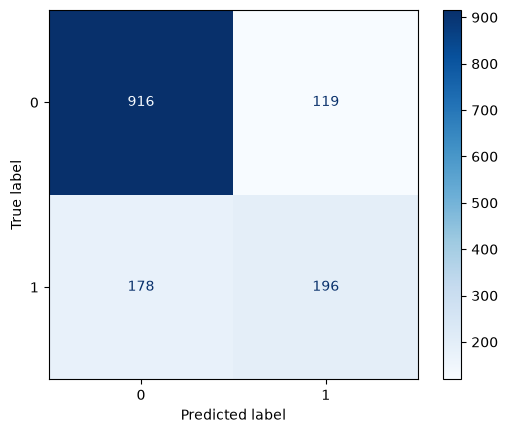

In [236]:
# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    log_model,
    X_test,
    y_test,
    cmap = "Blues"
)
plt.show()

Interpretation
- 916 customers correctly predicted as not churning (True Negatives).
- 196 customers correctly predicted as churning (True Positives).
- 119 loyal customers incorrectly flagged as churners (False Positives).
- 178 churning customers were missed (False Negatives).

In [238]:
# Cross-Validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    log_model,
    X, 
    y,
    cv = 5,
    scoring = "accuracy"
)

print("Cross Validation Scores:", cv_scores * 100)
print(f"Mean Accuracy: {cv_scores.mean() * 100: .2f}%")
print(f"Standard Deviation: {cv_scores.std() * 100: .2f}%")

Cross Validation Scores: [80.05677786 79.77288857 79.13413769 81.32102273 81.67613636]
Mean Accuracy:  80.39%
Standard Deviation:  0.96%


If the mean cross-validation accuracy is close to the test accuracy (around 79%), it indicates the model is stable and not heavily dependent on a particular split.

## Create the Results Table for Comparing Different Models

In [241]:
results = pd.DataFrame(columns=[
    "Model",
    "Training_Accuracy",
    "Test_Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC",
    "CV_Accuracy"
])

## Updating the Table

In [243]:
results.loc[len(results)] = [
    "Logistic Regression",
    81.03,
    78.92,
    62.22,
    52.41,
    56.89,
    70.45,
    80.39
]

In [244]:

results

,Model,Training_Accuracy,Test_Accuracy,Precision,Recall,F1,ROC_AUC,CV_Accuracy
0,Logistic Regression,81.03,78.92,62.22,52.41,56.89,70.45,80.39


# Building Model: Decision Tree

In [246]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth = 5,
    min_samples_split = 20,
    min_samples_leaf = 10,
    random_state = 42)
dt_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [247]:
y_pred_dt = dt_model.predict(X_test)
y_pred_train_dt = dt_model.predict(X_train)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

In [248]:
# Model Evaluation
print(f"Accuracy Train Model: {accuracy_score(y_train, y_pred_train_dt) * 100: .2f}%")
print(f"Accuracy Test Model: {accuracy_score(y_test, y_pred_dt) * 100: .2f}%")
print(f"Precision: {precision_score(y_test, y_pred_dt) * 100: .2f}%")
print(f"Recall: {recall_score(y_test, y_pred_dt) * 100: .2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred_dt) * 100: .2f}%")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_dt) * 100: .2f}%")

Accuracy Train Model:  80.26%
Accuracy Test Model:  78.71%
Precision:  60.05%
Recall:  59.09%
F1 Score:  59.57%
ROC-AUC:  72.44%


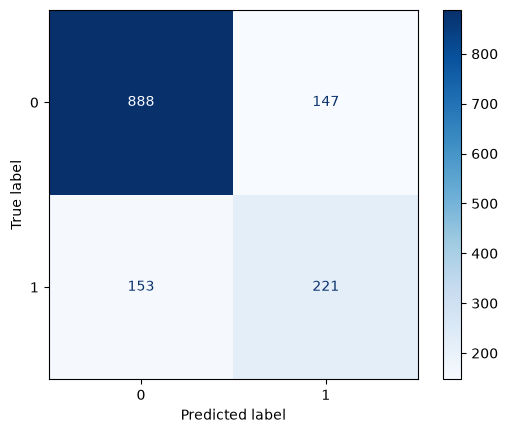

In [249]:
# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    dt_model,
    X_test,
    y_test,
    cmap = "Blues"
)
plt.show()

In [250]:
# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred_dt))

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.86      0.86      1035
           1       0.60      0.59      0.60       374

    accuracy                           0.79      1409
   macro avg       0.73      0.72      0.73      1409
weighted avg       0.79      0.79      0.79      1409



In [251]:
# Cross-Validation
cv_scores = cross_val_score(
    dt_model,
    X,
    y,
    cv = 5, 
    scoring = "accuracy"
)

print("Cross Validation Scores:", cv_scores * 100)
print(f"Mean Accuracy: {cv_scores.mean() * 100: .2f}%")

Cross Validation Scores: [78.42441448 77.85663591 78.35344216 79.33238636 78.83522727]
Mean Accuracy:  78.56%


#### Feature Importance

In [253]:
feature_importance = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": dt_model.feature_importances_ * 100
    })
    .sort_values(by = "Importance", ascending = False)
)

feature_importance.head(10)

,Feature,Importance
4,tenure,44.131864
11,InternetService_Fiber optic,33.673181
8,TotalCharges,4.403487
23,StreamingMovies_No internet service,3.573810
28,PaymentMethod_Electronic check,3.354350
7,MonthlyCharges,2.984702
26,Contract_Two year,2.143843
10,MultipleLines_Yes,2.023496
25,Contract_One year,0.988709
15,OnlineBackup_No internet service,0.927181


#### Plot Feature Importance

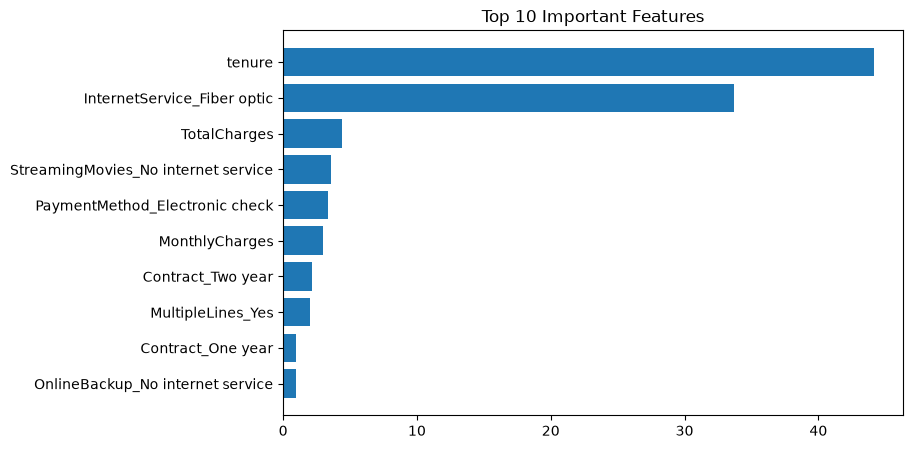

In [255]:
top10 = feature_importance.head(10)

plt.figure(figsize = (8, 5))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

#### Hyperparameter Tuning

In [257]:
from sklearn.model_selection import GridSearchCV

dt_classifier = DecisionTreeClassifier(random_state = 42)

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 5, 7, 10],
    'min_samples_split': [10, 13, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8, 10],
    'max_features': [None, 'sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=dt_classifier, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Optimal Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score: {grid_search.best_score_ * 100:.4f}%")

Optimal Hyperparameters: {'criterion': 'entropy', 'max_depth': 7, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 10}
Best Cross-Validation Score: 79.2510%


In [258]:
best_dt = grid_search.best_estimator_
test_accuracy = best_dt.score(X_test, y_test)
training_accuracy = best_dt.score(X_train, y_train)
print(f"Training Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Training Accuracy: 0.7878
Test Accuracy: 0.7878


## Update the Result Table

In [260]:
results.loc[len(results)] = [
    "Decision Tree",
    80.26,
    78.78,
    60.05,
    59.09,
    59.57,
    72.44,
    79.25
]

In [261]:
results

,Model,Training_Accuracy,Test_Accuracy,Precision,Recall,F1,ROC_AUC,CV_Accuracy
0,Logistic Regression,81.03,78.92,62.22,52.41,56.89,70.45,80.39
1,Decision Tree,80.26,78.78,60.05,59.09,59.57,72.44,79.25


Logistic Regression
- Better overall accuracy
- Better precision
- More stable across different data splits
- Simpler and easier to interpret
Decision Tree
- Better recall
- Better F1-score
- Better ROC-AUC
- More churners identified

Confusion Matrix Analysis

Compared to Logistic Regression:

-> Logistic Regression:

* True Positives = 196

-> Decision Tree:

* True Positives = 221

That's 25 additional churning customers correctly identified.

However:

False Positives increased:

Logistic = 119
Decision Tree = 147

So the business trade-off is:

Contact 28 extra loyal customers
Save 25 additional customers who would otherwise churn

Depending on the cost of outreach versus customer loss, that trade-off may be worthwhile.

# Building Model: Random Forest

In [265]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state = 42
)

rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [266]:
y_pred_rf = rf_model.predict(X_test)
y_pred_train_rf = rf_model.predict(X_train)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [267]:
# Model Evaluation

print(f"Accuracy Train Model: {accuracy_score(y_train, y_pred_train_rf) * 100: .2f}%")
print(f"Accuracy Test Model: {accuracy_score(y_test, y_pred_rf) * 100: .2f}%")
print(f"Precision: {precision_score(y_test, y_pred_rf) * 100: .2f}%")
print(f"Recall: {recall_score(y_test, y_pred_rf) * 100: .2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred_rf) * 100: .2f}%")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_rf) * 100: .2f}%")

Accuracy Train Model:  99.77%
Accuracy Test Model:  78.14%
Precision:  61.54%
Recall:  47.06%
F1 Score:  53.33%
ROC-AUC:  68.22%


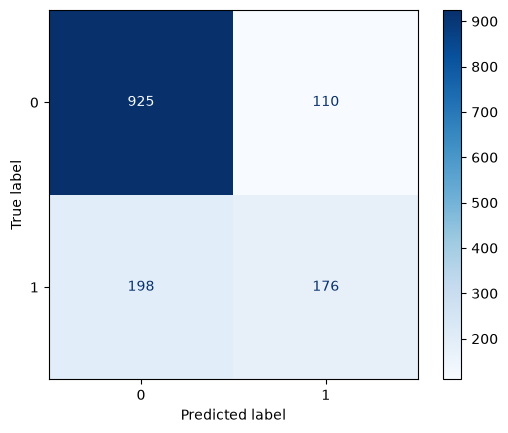

In [268]:
# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    cmap = "Blues"
)
plt.show()

In [269]:
# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.89      0.86      1035
           1       0.62      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [270]:
# Cross Validation

cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv = 5,
    scoring = "accuracy"
)

print("Cross Validation Scores:", cv_scores * 100)
print(f"Mean Accuracy: {cv_scores.mean() * 100: .2f}%")

Cross Validation Scores: [79.34705465 77.57274663 77.99858055 79.26136364 80.04261364]
Mean Accuracy:  78.84%


#### Hyperparameter Tuning 

In [272]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

random_search = RandomizedSearchCV(
    estimator = RandomForestClassifier(random_state = 42),
    param_distributions = param_dist,
    n_iter = 20,
    cv = 5,
    scoring = "accuracy",
    random_state = 42,
    n_jobs = -1,
    verbose = 2
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'max_depth': [5, 10, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichr

In [273]:
print("Best Parameters:", random_search.best_params_)
print(f"Best Cross Validation Score: {random_search.best_score_ * 100: .2f}%")

Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10, 'bootstrap': True}
Best Cross Validation Score:  80.49%


In [274]:
# Train Best Model
best_rf = random_search.best_estimator_
best_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [275]:
y_pred_best_rf = best_rf.predict(X_test)
y_pred_best_train_rf = best_rf.predict(X_train)
y_prob_best_rf = best_rf.predict_proba(X_test)[:, 1]

In [276]:
# Model Evaluation
print(f"Accuracy Train Model: {accuracy_score(y_train, y_pred_best_train_rf) * 100: .2f}%")
print(f"Accuracy Test Model: {accuracy_score(y_test, y_pred_best_rf) * 100: .2f}%")
print(f"Precision: {precision_score(y_test, y_pred_best_rf) * 100: .2f}%")
print(f"Recall: {recall_score(y_test, y_pred_best_rf) * 100: .2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred_best_rf) * 100: .2f}%")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_best_rf) * 100: .2f}%")

Accuracy Train Model:  85.20%
Accuracy Test Model:  79.49%
Precision:  64.91%
Recall:  49.47%
F1 Score:  56.15%
ROC-AUC:  69.90%


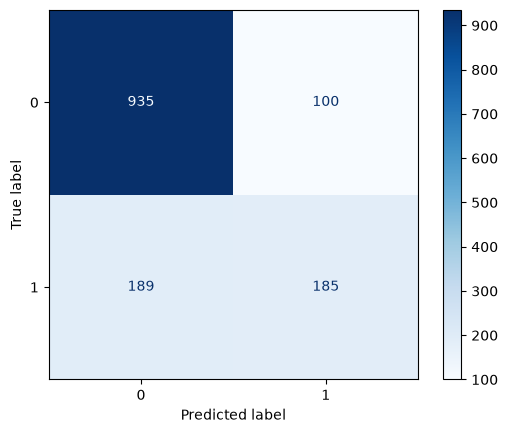

In [277]:
# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test,
    y_test,
    cmap = "Blues"
)
plt.show()

In [278]:
# Feature Importance
feature_importance = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_rf.feature_importances_ * 100
    })
    .sort_values(by = "Importance", ascending = False)
)

In [279]:
feature_importance.head(10)

,Feature,Importance
4,tenure,17.934222
8,TotalCharges,16.766998
7,MonthlyCharges,10.462465
11,InternetService_Fiber optic,6.638752
26,Contract_Two year,6.633748
28,PaymentMethod_Electronic check,6.287996
25,Contract_One year,3.427792
20,TechSupport_Yes,3.184807
14,OnlineSecurity_Yes,2.882111
6,PaperlessBilling,2.270711


## Update the Resuts Table

In [281]:
results.loc[len(results)] = [
    "Random Forest",
    85.20,
    79.49,
    64.91,
    49.47,
    56.15,
    69.90,
    80.49
]

In [282]:
results

,Model,Training_Accuracy,Test_Accuracy,Precision,Recall,F1,ROC_AUC,CV_Accuracy
0,Logistic Regression,81.03,78.92,62.22,52.41,56.89,70.45,80.39
1,Decision Tree,80.26,78.78,60.05,59.09,59.57,72.44,79.25
2,Random Forest,85.20,79.49,64.91,49.47,56.15,69.90,80.49


- Customers with short tenure churn more.
- Contract type is influential.
- Fiber optic customers have higher churn.
- Electronic check is associated with churn.
- Tech support and online security reduce churn risk.

## Creating a reusable evaluation function

In [285]:

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Accuracy Train Model": accuracy_score(y_train, model.predict(X_train)) * 100,
        "Accuracy Test Model": accuracy_score(y_test, y_pred) * 100,
        "Precision": precision_score(y_test, y_pred) * 100,
        "Recall": recall_score(y_test, y_pred) * 100,
        "F1 Score": f1_score(y_test, y_pred) * 100,
        "ROC-AUC Score": roc_auc_score(y_test, y_pred) * 100,
    }

# Buiding Model: XGBoost

In [287]:
# pip install xgboost

In [288]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state = 42,
    eval_metric = "logloss"
)
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [289]:
results_xgb = evaluate_model(
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

print(results_xgb)

{'Accuracy Train Model': 93.46822861199858, 'Accuracy Test Model': 78.06955287437899, 'Precision': 59.36599423631124, 'Recall': 55.080213903743314, 'F1 Score': 57.14285714285714, 'ROC-AUC Score': 70.7285127489731}


In [290]:
# Cross-Validation
cv_scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv = 5,
    scoring = "accuracy"
)

print("Cross Validation Scores:", cv_scores * 100)
print(f"Mean Accuracy: {cv_scores.mean() * 100: .2f}%")

Cross Validation Scores: [78.92122072 76.93399574 76.86302342 79.82954545 80.04261364]
Mean Accuracy:  78.52%


#### Hyperparameter Tuning

In [292]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1],
    "colsample_bytree": [0.8, 1],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3]
}

random_search = RandomizedSearchCV(
    estimator = XGBClassifier(
            random_state = 42,
            eval_metric = "logloss"
    ),
    param_distributions = param_dist,
    n_iter = 20, 
    cv = 5,
    scoring = "accuracy",
    random_state = 42,
    n_jobs = -1
)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 1], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multi

In [293]:
print("Best Parameters:", random_search.best_params_)
print(f"Best Cross Validation Score: {random_search.best_score_ * 100: .2f}%")

Best Parameters: {'subsample': 1, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 1}
Best Cross Validation Score:  80.64%


In [294]:
best_xgb = random_search.best_estimator_

results_xgb = evaluate_model(
    best_xgb,
    X_train,
    X_test,
    y_train,
    y_test
)

y_pred = best_xgb.predict(X_test)

print(results_xgb)

{'Accuracy Train Model': 82.51686190983317, 'Accuracy Test Model': 79.347054648687, 'Precision': 63.17460317460317, 'Recall': 53.20855614973262, 'F1 Score': 57.76487663280116, 'ROC-AUC Score': 71.0004133405668}


In [295]:
# Feature Importance
importance = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_xgb.feature_importances_ * 100
    })
    .sort_values(by = "Importance", ascending = False)
)
importance.head(15)

,Feature,Importance
11,InternetService_Fiber optic,23.147642
26,Contract_Two year,21.258493
25,Contract_One year,14.463083
12,InternetService_No,8.887868
4,tenure,6.190468
28,PaymentMethod_Electronic check,5.737494
24,StreamingMovies_Yes,2.831799
6,PaperlessBilling,2.365977
20,TechSupport_Yes,2.141612
14,OnlineSecurity_Yes,2.021162


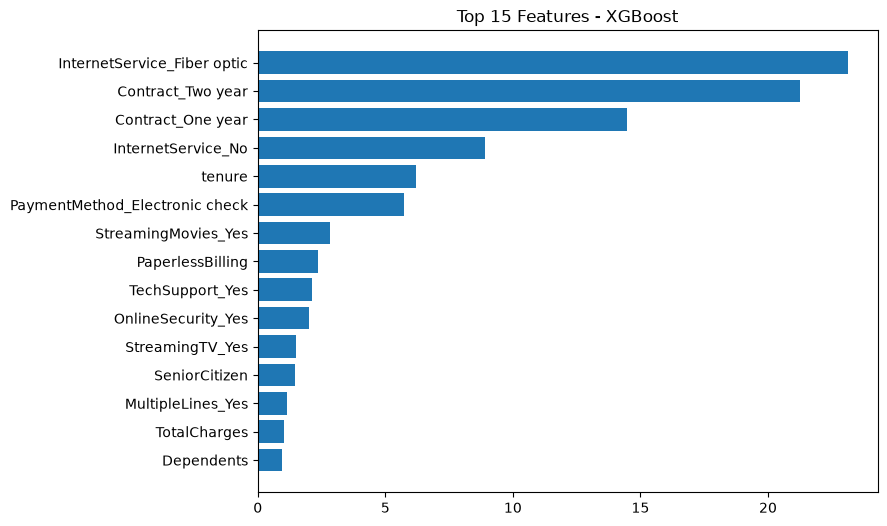

In [296]:
# Plot

top15 = importance.head(15)

plt.figure(figsize = (8, 6))

plt.barh(
    top15["Feature"],
    top15["Importance"]
)

plt.gca().invert_yaxis()
plt.title("Top 15 Features - XGBoost")
plt.show()

In [297]:
# Classification Report 
y_pred = best_xgb.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.78      0.79      0.79      1409



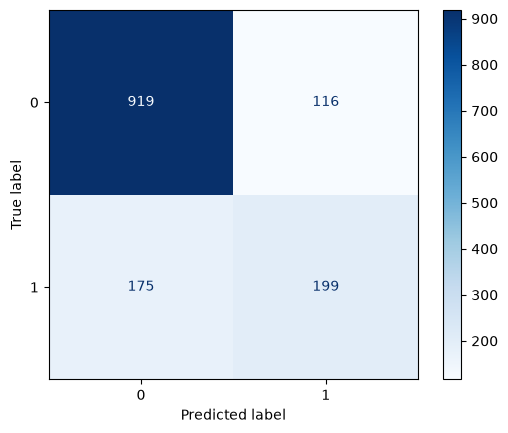

In [391]:
# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    best_xgb,
    X_test,
    y_test,
    cmap = "Blues"
)
plt.savefig("../artifacts/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [299]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc_value = roc_auc_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(accuracy, precision, recall, f1, roc_auc_value, "\n", cm)

0.7934705464868701 0.6317460317460317 0.5320855614973262 0.5776487663280117 0.7100041334056679 
 [[919 116]
 [175 199]]


In [300]:
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc_value
}

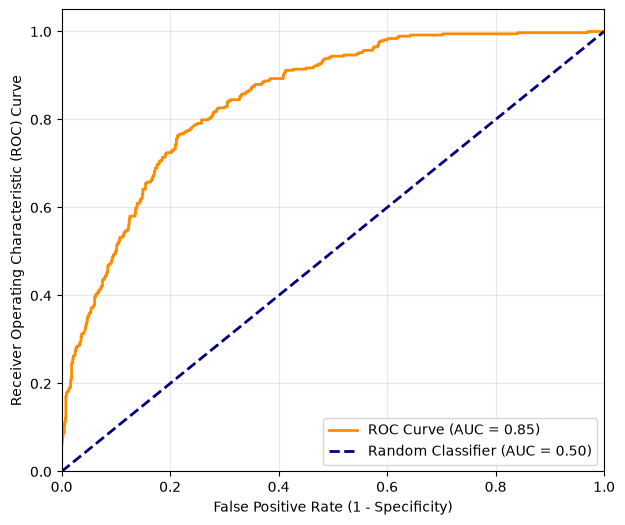

In [301]:
from sklearn.metrics import roc_curve, auc

y_probs = best_xgb.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_probs)

roc_auc = auc(fpr, tpr)

plt.figure(figsize = (7, 6))
plt.plot(fpr, tpr, color = "darkorange", lw = 2, label = f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color = "navy", lw = 2, linestyle = "--", label = "Random Classifier (AUC = 0.50)")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc = "lower right")
plt.grid(True, alpha = 0.3)

plt.show()

In [397]:
# fpr_tpr = pd.DataFrame({
#     "False Positive Rate": fpr,
#     "True Positive Rate": tpr
# })

fpr_tpr.to_csv("../artifacts/fpr_tpr.csv", index = False)

In [302]:
roc_data = {
    "fpr": fpr,
    "tpr": tpr,
    "roc_auc": roc_auc
}

print(fpr)
print(30 * "-")
print(tpr)
print(30 * "-")
print(roc_auc)

[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 9.66183575e-04 9.66183575e-04 1.93236715e-03
 1.93236715e-03 1.93236715e-03 2.89855072e-03 2.89855072e-03
 4.83091787e-03 4.83091787e-03 4.83091787e-03 4.83091787e-03
 5.79710145e-03 5.79710145e-03 6.76328502e-03 6.76328502e-03
 7.72946860e-03 7.72946860e-03 8.69565217e-03 8.69565217e-03
 1.06280193e-02 1.06280193e-02 1.25603865e-02 1.25603865e-02
 1.35265700e-02 1.35265700e-02 1.64251208e-02 1.64251208e-02
 1.64251208e-02 1.73913043e-02 1.73913043e-02 1.83574879e-02
 1.83574879e-02 1.83574879e-02 1.83574879e-02 2.02898551e-02
 2.02898551e-02 2.12560386e-02 2.12560386e-02 2.31884058e-02
 2.31884058e-02 2.51207729e-02 2.51207729e-02 2.60869565e-02
 2.60869565e-02 2.70531401e-02 2.70531401e-02 2.99516908e-02
 2.99516908e-02 3.28502415e-02 3.28502415e-02 3.38164251e-02
 3.38164251e-02 3.47826087e-02 3.57487923e-02 3.57487923e-02
 3.67149758e-02 3.67149758e-02 4.05797101e-02 4.05797101e-02
 4.34782609e-02 4.347826

Compared with Logistic Regression:

- Logistic Regression correctly identified 196 churners.
- XGBoost correctly identified 199 churners.

A small improvement, but with slightly better overall balance.

In [387]:
# import joblib
# import json
importance.head(10).to_csv("../artifacts/feature_importance.csv", index = False)
# joblib.dump(metrics, "../artifacts/model_metrics.pkl")
# joblib.dump(cm, "../artifacts/confusion_matrix.pkl")
# joblib.dump(importance, "../artifacts/feature_importance.pkl")
# joblib.dump(X_test, "../artifacts/X_test.pkl")
# joblib.dump(y_test, "../artifacts/y_test.pkl")
# joblib.dump(roc_data, "../artifacts/roc_curve.pkl")

## Update the Results Table

In [ ]:
results.loc[len(results)] = [
    "XGBoost",
    82.51, 
    79.34, 
    63.17,
    53.20,
    57.76,
    71.00,
    80.63 
]

In [ ]:
results

Decision Tree emphasized:
- tenure

Random Forest emphasized:
- tenure
- TotalCharges
  
XGBoost emphasizes:
- Contract type
- Internet service
- tenure

This tells us that contract type becomes much more influential when the model learns interactions between variables.

That is a valuable business insight.

Summary:
Customers with month-to-month contracts, Fiber optic service, electronic check payments, and shorter tenure are at the greatest risk of churning. Offering incentives to move these customers to longer-term contracts, promoting automatic payment methods, and strengthening early customer engagement may help reduce churn.

# Building Model: LightGBM

In [ ]:
# pip install lightgbm

In [ ]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    random_state = 42,
    verbose = -1
)

lgbm.fit(X_train, y_train)

In [ ]:
# Model Evaluation
from sklearn.metrics import roc_auc_score

results_lgbm = evaluate_model(
    lgbm,
    X_train,
    X_test,
    y_train,
    y_test
)
print(results_lgbm)

In [ ]:
# Cross Validation

cv_scores = cross_val_score(
    lgbm,
    X, 
    y,
    cv = 5,
    scoring = "accuracy"
)

print("Cross Validation Scores:", cv_scores * 100)
print(f"Mean Accuracy: {cv_scores.mean() * 100: .2f}%")

#### Hyperparameter Tuning

In [ ]:
param_dist = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7, -1],
    "num_leaves": [15, 31, 63],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_samples": [10, 20, 30]
}

random_search = RandomizedSearchCV(
    estimator = LGBMClassifier(
        random_state = 42,
        verbose = -1
    ),
    param_distributions = param_dist,
    n_iter = 20,
    cv = 5,
    scoring = "accuracy",
    random_state = 42,
    n_jobs = -1
)

random_search.fit(X_train, y_train)

In [ ]:
print("Best Parameters:", random_search.best_params_)
print(f"Best Cross Validation Score: {random_search.best_score_ * 100: .2f}")

In [ ]:
best_lgbm = random_search.best_estimator_

results_lgbm = evaluate_model(
    best_lgbm,
    X_train,
    X_test,
    y_train,
    y_test 
)

print(results_lgbm)

#### Feature Importance

In [ ]:
importance = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_lgbm.feature_importances_
    })
    .sort_values(
        by = "Importance", ascending = False
    )
)

importance.head(15)

In [ ]:
# Confusion Matrix 
ConfusionMatrixDisplay.from_estimator(
    best_lgbm,
    X_test,
    y_test,
    cmap = "Blues"
)
plt.show()

## Updating the Results Table

In [ ]:
results.loc[len(results)] = [
    "LightGBM",
    82.46, 
    79.06, 
    63.12, 
    50.80, 
    56.29, 
    70.03,
    80.81
]
results

# Building Model: CatBoost 

In [ ]:
# pip install catboost

In [ ]:
# Base Model
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    random_state = 42,
    verbose = 0
)

cat_model.fit(X_train, y_train)

In [ ]:
# Evaluating Model
results_cat = evaluate_model(
    cat_model,
    X_train,
    X_test,
    y_train,
    y_test
)

print(results_cat)

#### Cross-Validation

In [ ]:
cv_scores = cross_val_score(
    cat_model,
    X,
    y,
    cv = 5,
    scoring = "accuracy"
)

print("Cross Validation Score:", cv_scores)
print("Mean Accuracy:", cv_scores.mean() * 100)

#### Hyperparameter Tuning

In [ ]:
param_dist = {
    "iterations": [100, 200, 300],
    "depth": [4, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7],
    "border_count": [32, 64, 128]
}

random_search = RandomizedSearchCV(
    estimator = CatBoostClassifier(
        random_state = 42,
        verbose = 0
    ),
    param_distributions = param_dist,
    n_iter = 20, 
    cv = 5,
    scoring = "accuracy",
    random_state = 42,
    n_jobs = -1
)

random_search.fit(X_train, y_train)

In [ ]:
# Best Parameters

print("Best Parameters:", random_search.best_params_)
print(f"Best Cross Validation Score: {random_search.best_score_ * 100: .2f}")

In [ ]:
# Evaluate The Tuned Model

best_cat = random_search.best_estimator_

results_cat = evaluate_model(
    best_cat,
    X_train,
    X_test,
    y_train,
    y_test
)

print(results_cat)

#### Feature Importance

In [ ]:
imprtance = (
    pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_cat.feature_importances_
    })
    .sort_values(by = "Importance", ascending = False)
)
importance.head(15)

In [ ]:
# plot
top15 = importance.head(15)

plt.figure(figsize=(8,6))

plt.barh(
    top15["Feature"],
    top15["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Features - CatBoost")

plt.show()

In [ ]:
# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    best_cat,
    X_test,
    y_test,
    cmap = "Blues"
)
plt.show()

Compared to Logistic Regression:

- Logistic Regression correctly identified 196 churners.
CatBoost correctly identified 189 churners.

- CatBoost produced fewer false positives but also identified fewer churners, illustrating the common precision–recall trade-off.

## Updating the Results Table

In [ ]:
results.loc[len(results)] = [
    "CatBoost",
    81.54,
    79.63,
    64.94,
    50.53,
    56.84,
    70.33,
    80.80
]
results

## I chose the XGBoost as the final deployment model.

Although CatBoost has the highest test accuracy (79.63%), the difference is only 0.29%, which is very small and unlikely to be meaningful in practice.

XGBoost provides a stronger overall balance:

- High test accuracy (79.34%)
- Better recall than Random Forest, LightGBM, and CatBoost
- Strong F1-score (57.76%)
- Good ROC-AUC (71.00%)
- Excellent cross-validation performance (80.63%)
- One of the most widely used algorithms in industry for tabular data

For a churn prediction system, having a balanced model is usually more valuable than gaining a tiny improvement in accuracy while losing recall.

#### Summary 

Among the six evaluated machine learning algorithms, XGBoost was selected as the final predictive model due to its balanced performance across multiple evaluation metrics. Although CatBoost achieved the highest test accuracy (79.63%), the improvement over XGBoost (79.34%) was marginal. XGBoost demonstrated a superior balance between precision (63.17%), recall (53.20%), F1-score (57.76%), ROC-AUC (71.00%), and cross-validation accuracy (80.63%), indicating strong predictive capability and generalization performance. Therefore, XGBoost was considered the most suitable model for deployment in the customer churn prediction system.

## Save the Final Model

In [ ]:
# import joblib 

# joblib.dump(best_xgb, "../models/xgboost_model.pkl")

## Save the Scaler

In [ ]:
# joblib.dump(scaler, "../models/scaler.pkl")

## Save Feature Names

In [ ]:
# feature_columns = X.columns.tolist()

# joblib.dump(feature_columns, "../models/feature_columns.pkl")

## Verify Everything

In [ ]:
# import os

# print(os.listdir("../models"))

## Save the Results Table

In [192]:
results.to_csv("../artifacts/model_comparison.csv", index = False)